# Capacitated Vehicle Routing Problem (CLEMO)

This notebook reproduces the **Capacitated Vehicle Routing Problem (CVRP)**
experiment from *"Coherent Local Explanations for Mathematical
Optimization"* (Section 4.3): explaining a **heuristic** solver (Google
OR-Tools) where, unlike the SPP and KP experiments, the underlying algorithm
is not guaranteed to return an optimal solution.

The sensitive parameters are the client demands `d` and the costs `c_0` of
the arcs between the depot and each client. We explain (i) the objective
value, and (ii) which arcs into the depot (node 0) are used in the solution.

Reproduces:

- **Table 4** -- fidelity and incoherence of LR vs. CLEMO.
- **Figure 3** -- CLEMO's explanation of the objective value, visualized on
  the present-problem network plus a bar chart of the top-10 feature
  contributions.
- **Figure D.9** (appendix) -- the same, for decision variable `x_(2,0)`
  (whether arc (2,0) is used).

Runtime: dominated by 1000 OR-Tools solves (5s time limit each) during
dataset creation -- expect this to take roughly 1-1.5 hours. The CLEMO fit
itself (SLSQP, ~1000 iterations on a ~64-dimensional beta) takes a few
minutes.


## 1. Setup

In [1]:
import copy
import time
from dataclasses import dataclass
from typing import Callable, List, Tuple

import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.optimize import check_grad, minimize
from sklearn.linear_model import LinearRegression, LogisticRegression

from ortools.constraint_solver import pywrapcp, routing_enums_pb2


## 2. Problem instance

A CVRP instance with 16 clients + 1 depot (`nr_lctns = 17`) and 4 vehicles
of capacity 150, using Manhattan distances between fixed coordinates.


In [2]:
# Global settings
nr_lctns = 17     # 1 depot + 16 clients
nr_vhcls = 4
capacity = 150
smple_sz = 1000
epsilon = 10e-4

# Implied dimensions
nr_trgts = nr_lctns * (nr_lctns - 1) + 1   # objective value + all arc indicators
nr_ftres = 2 * (nr_lctns - 1)               # demands (excl. depot) + costs to depot (excl. depot)
nr_ftres_intrcpt = nr_ftres + 1

# Set seed for reproducibility
np.random.seed(42)

In [3]:
def manhattan_dist(coordinates):
    """Pairwise Manhattan distances between `coordinates`."""
    dst = np.zeros((nr_lctns, nr_lctns), dtype=int)
    for i in range(nr_lctns):
        for j in range(nr_lctns):
            dst[i, j] = int(np.abs(np.sum(np.array(coordinates[i]) - np.array(coordinates[j]))))
    return dst


# Present problem: 16 clients + depot, fixed coordinates
data = {
    'coordinates': [
        [456, 320],  # 0: depot
        [228, 0], [912, 0], [0, 80], [114, 80], [570, 160], [798, 160],
        [342, 240], [684, 240], [570, 400], [912, 400], [114, 480],
        [228, 480], [342, 560], [684, 560], [0, 640], [798, 640],
    ],
    'demands': [0, 15, 12, 26, 40, 20, 34, 55, 65, 13, 20, 10, 16, 40, 27, 64, 70],
    'vehicle_capacities': [capacity] * nr_vhcls,
    'num_vehicles': nr_vhcls,
    'depot': 0,
}
data['distance_matrix'] = manhattan_dist(data['coordinates'])


In [4]:
# Edge list (directed arcs, excluding self-loops) and per-node incoming/outgoing arc indices
edge_list = [(i, j) for i in range(nr_lctns) for j in range(nr_lctns) if i != j]

in_indx_dict = {str(i): [] for i in range(nr_lctns)}
out_indx_dict = {str(i): [] for i in range(nr_lctns)}
for idx, (i, j) in enumerate(edge_list):
    out_indx_dict[str(i)].append(idx)
    in_indx_dict[str(j)].append(idx)


def dist_list(dst_matrix):
    """Flatten a distance matrix into a 1D cost vector, ordered as `edge_list`."""
    return [dst_matrix[i][j] for i, j in edge_list]

## 3. Solver: Google OR-Tools heuristic

`decoded_VRP_solver` is the solution algorithm `h` from Eq. (2): given
demands and a distance matrix, it runs the OR-Tools routing heuristic
(guided local search, 5s time limit) and returns the total route distance
(objective value), the cumulative-load vector `u` (used for the capacity
constraints), and the arc-indicator vector `x`.


In [5]:
def decoded_VRP_solver(demand, distance_matrix, goal='all', verbose=False):
    """Solve the CVRP with OR-Tools and decode the solution.

    Args:
        demand: per-node demand vector (length nr_lctns, depot = 0).
        distance_matrix: pairwise distances (nr_lctns x nr_lctns).
        goal: 'all' returns (objective, u, x); 'objective' returns just the
            total distance.
        verbose: print the OR-Tools solution summary.

    Returns:
        See `goal`. `u` is the cumulative load vector (Eq. A.2, capacity
        constraints); `x` is the binary arc-indicator vector, ordered as
        `edge_list`.
    """
    # Create the routing index manager.
    manager = pywrapcp.RoutingIndexManager(len(distance_matrix), data['num_vehicles'], data['depot'])
    
    # Create Routing Model.
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        return distance_matrix[manager.IndexToNode(from_index)][manager.IndexToNode(to_index)]

    transit_idx = routing.RegisterTransitCallback(distance_callback)
    
    # Set cost of each arc.
    routing.SetArcCostEvaluatorOfAllVehicles(transit_idx)

    def demand_callback(from_index):
        return demand[manager.IndexToNode(from_index)]

    demand_idx = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(
        demand_idx, 0, data['vehicle_capacities'], True, 'Capacity')

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    search_parameters.time_limit.FromSeconds(5)

    # Solve the problem
    solution = routing.SolveWithParameters(search_parameters)

    total_distance = 0
    edges_used = []
    u_vctr = np.zeros(nr_lctns)

    for vehicle_id in range(nr_vhcls):
        index = routing.Start(vehicle_id)
        route_load = 0
        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            route_load += demand[node]
            u_vctr[node] = route_load
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            total_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)
            if routing.IsEnd(index):
                edges_used.append((previous_index, 0))
            elif routing.IsStart(previous_index):
                edges_used.append((0, index))
            else:
                edges_used.append((previous_index, index))

    x_vctr = [1 if edge in edges_used else 0 for edge in edge_list]

    if goal == 'all':
        return total_distance, u_vctr, x_vctr
    elif goal == 'objective':
        return total_distance
    raise ValueError(f"Unsupported goal: {goal!r}")


In [6]:
# Sanity check: solve the present problem (theta = nominal demands/distances)
total_distance, u_vctr, x_vctr = decoded_VRP_solver(demand=data['demands'], distance_matrix=data['distance_matrix'])
print('Total distance of present problem:', total_distance)


Total distance of present problem: 3352


## 4. Feasible region: capacity, flow, and subtour-elimination constraints

The feasible region `X(theta)` is given by the Miller-Tucker-Zemlin
formulation (Eq. A.2, Appendix A): capacity bounds on the cumulative load
`u`, flow-conservation at every client and the depot, and subtour
elimination. As in the SPP notebook, `flow_constraints` /
`cap_constraints` / `subtour_constraints` evaluate these for batches of
(possibly fractional, predicted) decision vectors; the `jac_*` variants
give the corresponding Jacobians used by the CLEMO subgradient.


In [7]:
def cap_constraints(u, d, capacity):
    """Capacity bound violations: d_j <= u_j <= capacity for all j (Eq. A.2)."""
    u, d = np.array(u), np.array(d)
    constraints = []
    for i in range(nr_lctns):
        constraints.append(np.maximum(0, d[:, i] - u[:, i]))
        constraints.append(np.maximum(0, u[:, i] - capacity))
    return np.transpose(np.array(constraints))


def flow_constraints(x):
    """Flow-conservation residuals (Eq. A.2) for a batch of arc-indicator vectors."""
    x = np.array(x)
    constraints = []
    for i in range(nr_lctns):
        if i == 0:
            constraints.append(np.maximum(0, sum(x[:, j] for j in out_indx_dict['0']) - nr_vhcls))
            constraints.append(sum(x[:, j] for j in out_indx_dict['0']) - sum(x[:, k] for k in in_indx_dict['0']))
        else:
            constraints.append(sum(x[:, j] for j in out_indx_dict[str(i)]) - 1)
            constraints.append(sum(x[:, j] for j in in_indx_dict[str(i)]) - 1)
    return np.transpose(np.array(constraints))


def subtour_constraints(x, u, d, capacity):
    """Subtour-elimination residuals (Eq. A.2) for a batch of arc-indicator vectors."""
    x, u, d = np.array(x), np.array(u), np.array(d)
    constraints = []
    for strt, end in edge_list:
        if strt != 0 and end != 0:
            constraints.append(np.maximum(0, u[:, strt] - u[:, end] + capacity * x[:, edge_list.index((strt, end))]
                                           - (capacity - d[:, end])))
        else:
            constraints.append(np.zeros(len(x)))
    return np.transpose(np.array(constraints))


# Incidence matrix mapping the 2*nr_lctns flow constraints to the arc variables,
# used to apply the chain rule when differentiating `flow_constraints`.
_FLOW_INCIDENCE = np.zeros((2 * nr_lctns, len(edge_list)))
for i in range(nr_lctns):
    for j in out_indx_dict[str(i)]:
        _FLOW_INCIDENCE[2 * i][j] = 1.0
    for j in in_indx_dict[str(i)]:
        _FLOW_INCIDENCE[2 * i + 1][j] = -1.0 if i == 0 else 1.0


def jac_flow_constraints(x):
    """Jacobian of `flow_constraints` w.r.t. the arc-indicator variables."""
    return np.matmul(flow_constraints(x), _FLOW_INCIDENCE)


def jac_subtour_constraints(x, u, d, capacity):
    """Jacobian of `subtour_constraints` w.r.t. the arc-indicator variables."""
    return capacity * (subtour_constraints(x, u, d, capacity) > 0)


## 5. Sampling: building the dataset

We explain `node_of_interest = 0` (the depot): the objective value, and
which arcs into the depot are used in the present solution. Parameters
`theta = (d, c_0)` are perturbed multiplicatively (demands and the depot's
distance row/column).


In [9]:
node_of_interest = 0


def sample_perturbations_normal(orig, mean=0, var=0.2, size=1000, feasibility_check=True):
    """Draw `size` multiplicative perturbations of `orig` (rounded to int).

    With `feasibility_check=True`, perturbed demand vectors are accepted
    only if their total stays below 80% of the fleet's total capacity (a
    rule-of-thumb feasibility check for the CVRP).
    """
    samples = [orig]
    while len(samples) < size:
        candidate = copy.deepcopy(orig)
        for j in range(len(orig)):
            candidate[j] = int(candidate[j] + np.random.normal(mean, candidate[j] * var))
        if (not feasibility_check) or (np.sum(candidate) <= capacity * 0.8 * nr_vhcls):
            samples.append(np.asarray(candidate))
    return np.asarray(samples)


def get_values_from_samples(samples, model, hyperparams=None):
    """Apply `model` to each sampled demand vector and collect h(theta_i)."""
    hyperparams = hyperparams or {}
    return [model(demand=s, **hyperparams) for s in samples]


def std_weight_function(a, b, ftr_index_list, kernel_width=None):
    """RBF kernel weight w_i = exp(-d(a,b)^2 / nu^2), Eq. (11)."""
    d = np.linalg.norm(a - b)
    nu = (0.75 * len(ftr_index_list)) if kernel_width is None else kernel_width
    return np.exp(-(d ** 2) / (2 * nu ** 2))


def get_weights_from_samples(samples, ftr_index_list, function=None, width=None):
    """RBF weights of all samples relative to the first sample (theta_0)."""
    origin = samples[0]
    if function is not None:
        return [function(origin, s) for s in samples]
    return [std_weight_function(origin, s, ftr_index_list, width) for s in samples]


def sig(x):
    """Numerically stable sigmoid, clipped outside [-30, 30]."""
    x = np.asarray(x)
    out = np.empty_like(x, dtype=float)
    out[x > 30] = 1.0
    out[x < -30] = 0.0
    mask = (x >= -30) & (x <= 30)
    out[mask] = 1 / (1 + np.exp(-x[mask]))
    return out


def lg1(x):
    """log(sigmoid(x)), clipped outside [-30, 30]."""
    x = np.asarray(x)
    out = np.empty_like(x, dtype=float)
    out[x > 30] = 0.0
    out[x < -30] = np.log(1 / (1 + np.exp(30)))
    mask = (x >= -30) & (x <= 30)
    out[mask] = np.log(1 / (1 + np.exp(-x[mask])))
    return out


def lg2(x):
    """log(1 - sigmoid(x)), clipped outside [-30, 30]."""
    x = np.asarray(x)
    out = np.empty_like(x, dtype=float)
    out[x < -30] = 0.0
    out[x > 30] = np.log(1 - 1 / (1 + np.exp(-30)))
    mask = (x >= -30) & (x <= 30)
    out[mask] = np.log(1 - 1 / (1 + np.exp(-x[mask])))
    return out


In [10]:
# Sample demands (all nr_lctns entries) and the depot's distance row independently
samples_dmnd_all = sample_perturbations_normal(data['demands'], size=smple_sz)
samples_dstn_noi = sample_perturbations_normal(
    data['distance_matrix'][node_of_interest], size=smple_sz, feasibility_check=False)

samples_dist_mtrx, samples_dist_list, samples_dstn_noi_wo = [], [], []
for sample_dstn in samples_dstn_noi:
    lcl_dstn = data['distance_matrix'].copy()
    lcl_dstn[node_of_interest] = sample_dstn
    lcl_dstn[:, node_of_interest] = sample_dstn
    samples_dist_mtrx.append(lcl_dstn)
    samples_dist_list.append(dist_list(lcl_dstn))
    samples_dstn_noi_wo.append(lcl_dstn[node_of_interest][1:])

# Features theta = (demands excl. depot, depot distances excl. depot), length nr_ftres
samples_ftrs = np.concatenate((samples_dmnd_all[:, 1:], samples_dstn_noi_wo), axis=1)
samples_dist_list = np.array(samples_dist_list)
features = list(range(nr_ftres))


In [11]:
# Solve the CVRP for every sample (the expensive step: 1000 OR-Tools solves)
actuals = {'objct': [], 'x_vct': [], 'u_vct': []}
d_list = []

for i in range(len(samples_ftrs)):
    sample_dmnd = samples_dmnd_all[i]
    sample_dist_mtrx = samples_dist_mtrx[i]
    if sum(sample_dmnd) >= capacity * nr_vhcls:
        print('Warning: infeasible total demand for sample', i)

    objct, u_vct, x_vct = decoded_VRP_solver(demand=sample_dmnd, distance_matrix=sample_dist_mtrx)
    actuals['objct'].append(objct)
    actuals['x_vct'].append(x_vct)
    actuals['u_vct'].append(u_vct)
    d_list.append(np.linalg.norm(samples_ftrs[0] - samples_ftrs[i]))

    if (i + 1) % (smple_sz // 10) == 0:
        print(f'{100 * (i + 1) / smple_sz:.0f}% done')

weights = get_weights_from_samples(samples_ftrs, features, width=np.mean(d_list))


10% done
20% done
30% done
40% done
50% done
60% done
70% done
80% done
90% done
100% done


In [12]:
# Rescale for numerical stability of SLSQP (doesn't affect relative feature contributions)
samples_ftrs = np.array(samples_ftrs) / 100
samples_ftrs_intrcpt = np.concatenate((samples_ftrs, np.ones((smple_sz, 1))), axis=1)
samples_dist_list = np.array(samples_dist_list) / 1000

actuals['objct'] = np.array(actuals['objct']) / 1000
actuals['x_vct'] = np.array(actuals['x_vct'])
actuals['u_vct'] = np.array(actuals['u_vct']) / 100


In [13]:
# Identify which arcs into the depot are used in the present solution -- these
# are the decision variables we explain alongside the objective value.
kc_indx = [i for i in in_indx_dict[str(node_of_interest)] if actuals['x_vct'][0][i] == 1]
print('Depot-incoming arcs used in the present solution:', [edge_list[i] for i in kc_indx])


Depot-incoming arcs used in the present solution: [(2, 0), (6, 0), (11, 0), (15, 0)]


## 6. Warm start (LR benchmark)

As in the SPP notebook, `get_warm_start_linreg` fits the LR benchmark of
Eq. (5): a `LinearRegression` for the objective value and a
`LogisticRegression` for each explained decision variable (skipping
variables that are constant across all samples).


In [14]:
def get_warm_start_linreg(X, Y, W, trgt_indx):
    """Fit independent linear/logistic regressions for the targets in `trgt_indx`.

    Args:
        X: design matrix (without intercept), shape (N, nr_ftres).
        Y: targets dict with 'objct' and 'x_vct'.
        W: RBF sample weights.
        trgt_indx: target indices to explain; index 0 (first entry) is
            treated as the objective value, the rest as decision variables.

    Returns:
        beta, shape (nr_ftres_intrcpt, len(kc_indx_revw) + 1), and
        kc_indx_revw: the subset of `trgt_indx[1:]` that were actually fit
        (decision variables with only one value across all samples are
        skipped).
    """
    models, kc_indx_revw = [], []
    X = np.array(X)

    for cnt, i in enumerate(trgt_indx):
        if cnt == 0:
            clf = LinearRegression()
            clf.fit(X, Y['objct'], sample_weight=W)
            models.append(clf)
            continue

        y_loc = np.array([z[i] for z in Y['x_vct']])
        if np.sum(y_loc) == len(y_loc):
            print('Decision variable always 1, skipping:', edge_list[i])
        elif np.sum(y_loc) == 0:
            print('Decision variable always 0, skipping:', edge_list[i])
        else:
            clf = LogisticRegression(max_iter=10_000)
            clf.fit(X, y_loc.astype(int), sample_weight=W)
            kc_indx_revw.append(i)
            models.append(clf)

    beta_T = np.zeros((len(models), nr_ftres_intrcpt))
    for i, model in enumerate(models):
        if any(isinstance(c, np.ndarray) for c in model.coef_):
            beta_T[i, :-1] = model.coef_[0]
            beta_T[i, -1] = model.intercept_[0]
        else:
            beta_T[i, :-1] = model.coef_
            beta_T[i, -1] = model.intercept_
    return np.transpose(beta_T), kc_indx_revw


trgt_indx = np.concatenate(([0], kc_indx))
wrm_strt_lcl, kc_indx_revw = get_warm_start_linreg(samples_ftrs, actuals, weights, trgt_indx)


## 7. Loss functions (Eq. 10)

Same loss decomposition as the SPP notebook (objective + decision-vector
fidelity, plus objective-coherence and feasibility regularizers), but with
the feasible region given by the MTZ constraints (`flow_constraints` +
`cap_constraints` + `subtour_constraints`). Note that `cap_constraints` is
evaluated on the *true* cumulative-load vector `u` (not predicted, since
`u` is not one of the explained outputs), with capacity rescaled to `1.5`
to match the `/100` feature rescaling above.


In [15]:
def _split_predictions(beta, X, Y, keep_columns):
    """Shared bookkeeping: objective/decision-vector predictions and the
    combined decision vector (predictions for `keep_columns`, true values elsewhere)."""
    pred = np.matmul(X, beta)
    obj_prd = pred[:, 0]
    dcv_prd = sig(pred[:, 1:])

    dcv_cmb = Y['x_vct'].copy().astype(float)
    columns_to_replace = np.zeros(dcv_cmb.shape[1], dtype=bool)
    columns_to_replace[keep_columns] = True
    dcv_cmb[:, columns_to_replace] = dcv_prd

    return obj_prd, dcv_prd, dcv_cmb


def lss_all(beta, X=samples_ftrs_intrcpt, Y=actuals, W=weights, lgr_std=1, lgr_log=1, lgr_obj=1,
            lgr_cns=1, oneD=True, C=samples_dist_list, keep_columns=kc_indx_revw):
    """Total CLEMO loss (Eq. 10) for the CVRP."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, len(keep_columns) + 1)

    W, X = np.array(W), np.array(X)
    X_demand = np.hstack((np.zeros((len(X), 1)), X[:, :nr_lctns - 1]))
    Y_x_vct_kp = Y['x_vct'][:, keep_columns]

    obj_prd, dcv_prd, dcv_cmb = _split_predictions(beta, X, Y, keep_columns)
    dcv_lg1, dcv_lg2 = lg1(np.matmul(X, beta)[:, 1:]), lg2(np.matmul(X, beta)[:, 1:])

    cns_arr_flow = flow_constraints(dcv_cmb)
    cns_arr_capc = cap_constraints(Y['u_vct'], X_demand, capacity=1.5)
    cns_arr_sbtr = subtour_constraints(dcv_cmb, Y['u_vct'], X_demand, capacity=1.5)

    std_err = np.sum(W * np.square(Y['objct'] - obj_prd))
    log_err = -np.sum(W * np.sum(Y_x_vct_kp * dcv_lg1 + (1 - Y_x_vct_kp) * dcv_lg2, axis=1))
    obj_err = np.sum(W * np.square(obj_prd - np.sum(dcv_cmb * C, axis=1)))
    cns_err = (np.sum(W * np.sum(np.square(cns_arr_flow), axis=1))
               + np.sum(W * np.sum(np.square(cns_arr_capc), axis=1))
               + np.sum(W * np.sum(cns_arr_sbtr, axis=1)))

    return lgr_std * std_err + lgr_cns * cns_err + lgr_log * log_err + lgr_obj * obj_err


def lss_all_jac_sg(beta, X=samples_ftrs_intrcpt, Y=actuals, W=weights, lgr_std=1, lgr_log=1, lgr_obj=1,
                   lgr_cns=1, oneD=True, C=samples_dist_list, keep_columns=kc_indx_revw):
    """(Sub)gradient of `lss_all`, used as the SLSQP Jacobian."""
    grad = np.zeros((nr_ftres_intrcpt, len(keep_columns) + 1))
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, len(keep_columns) + 1)

    W, X = np.array(W), np.array(X)
    X_demand = np.hstack((np.zeros((len(X), 1)), X[:, :nr_lctns - 1]))
    Y_x_vct_kp = Y['x_vct'][:, keep_columns]
    C_kp = C[:, keep_columns]

    obj_prd, dcv_prd, dcv_cmb = _split_predictions(beta, X, Y, keep_columns)

    tmp_std = Y['objct'] - obj_prd
    tmp_obj = obj_prd - np.sum(dcv_cmb * C, axis=1)
    tmp_cns_flow = jac_flow_constraints(dcv_cmb)[:, keep_columns]
    tmp_cns_sbtr = jac_subtour_constraints(dcv_cmb, Y['u_vct'], X_demand, capacity=1.5)[:, keep_columns]

    for k in range(grad.shape[0]):
        for j in range(grad.shape[1]):
            if j == 0:  # objective value column
                grad[k, j] -= 2 * lgr_std * np.sum(W * X[:, k] * tmp_std)
                grad[k, j] += 2 * lgr_obj * np.sum(W * X[:, k] * tmp_obj)
            else:  # decision-vector columns
                d = dcv_prd[:, j - 1]
                grad[k, j] -= lgr_log * (abs(beta[k, j]) < 30) * np.sum(
                    W * X[:, k] * (Y_x_vct_kp[:, j - 1] - d))
                grad[k, j] -= 2 * lgr_obj * np.sum(
                    W * d * (1 - d) * X[:, k] * C_kp[:, j - 1] * tmp_obj)
                grad[k, j] += 2 * lgr_cns * np.sum(
                    W * d * (1 - d) * X[:, k] * tmp_cns_flow[:, j - 1])
                grad[k, j] += lgr_cns * np.sum(
                    W * d * (1 - d) * X[:, k] * tmp_cns_sbtr[:, j - 1])

    return grad.flatten()


In [16]:
def lss_std(beta, X=samples_ftrs_intrcpt, Y=actuals, W=weights, oneD=True, keep_columns=kc_indx_revw):
    """Fidelity loss of the objective-value prediction (weighted squared error)."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, len(keep_columns) + 1)
    W, X = np.array(W), np.array(X)
    return np.sum(W * np.square(Y['objct'] - np.matmul(X, beta[:, 0])))


def lss_log(beta, X=samples_ftrs_intrcpt, Y=actuals, W=weights, oneD=True, keep_columns=kc_indx_revw):
    """Fidelity loss of the decision-vector predictions (weighted log loss)."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, len(keep_columns) + 1)
    W, X = np.array(W), np.array(X)
    Y_x_vct_kp = Y['x_vct'][:, keep_columns]
    dcv_lg1, dcv_lg2 = lg1(np.matmul(X, beta)[:, 1:]), lg2(np.matmul(X, beta)[:, 1:])
    return -np.sum(W * np.sum(Y_x_vct_kp * dcv_lg1 + (1 - Y_x_vct_kp) * dcv_lg2, axis=1))


def lss_obj(beta, X=samples_ftrs_intrcpt, Y=actuals, W=weights, oneD=True, C=samples_dist_list, keep_columns=kc_indx_revw):
    """Objective-coherence loss: violation of condition (3), R_C1."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, len(keep_columns) + 1)
    W, X = np.array(W), np.array(X)
    obj_prd, _, dcv_cmb = _split_predictions(beta, X, Y, keep_columns)
    return np.sum(W * np.square(obj_prd - np.sum(dcv_cmb * C, axis=1)))


def lss_cns(beta, X=samples_ftrs_intrcpt, Y=actuals, W=weights, oneD=True, keep_columns=kc_indx_revw):
    """Feasibility loss: violation of condition (4), R_C2 (flow + capacity + subtour)."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, len(keep_columns) + 1)
    W, X = np.array(W), np.array(X)
    X_demand = np.hstack((np.zeros((len(X), 1)), X[:, :nr_lctns - 1]))
    _, _, dcv_cmb = _split_predictions(beta, X, Y, keep_columns)

    cns_arr_flow = flow_constraints(dcv_cmb)
    cns_arr_capc = cap_constraints(Y['u_vct'], X_demand, capacity=1.5)
    cns_arr_sbtr = subtour_constraints(dcv_cmb, Y['u_vct'], X_demand, capacity=1.5)

    return (np.sum(W * np.sum(np.square(cns_arr_flow), axis=1))
            + np.sum(W * np.sum(np.square(cns_arr_capc), axis=1))
            + np.sum(W * np.sum(cns_arr_sbtr, axis=1)))


In [17]:
# Individual loss components at the LR warm start
print('Fidelity (objective)      :', lss_std(wrm_strt_lcl))
print('Fidelity (decision vector):', lss_log(wrm_strt_lcl))
print('Incoherence (objective)   :', lss_obj(wrm_strt_lcl))
print('Incoherence (feasibility) :', lss_cns(wrm_strt_lcl))

# Sanity check: the analytical subgradient matches a finite-difference gradient
print('Gradient check error      :', check_grad(lss_all, lss_all_jac_sg, wrm_strt_lcl.flatten()))


Fidelity (objective)      : 4.241521571342737
Fidelity (decision vector): 1207.4161883434163
Incoherence (objective)   : 12.347244188559653
Incoherence (feasibility) : 802.5450600217099
Gradient check error      : 0.0016614175426271419


## 8. Fitting CLEMO (Eq. 10)

As in the other notebooks, the four loss terms are balanced so that each
contributes with similar magnitude relative to the largest term (Section
4, Setup), then CLEMO is fit with SLSQP, warm-started at the LR solution.
The optimization history is tracked via a callback so the best-so-far
solution can be selected even if SLSQP's reported result is not the best
iterate.


In [18]:
def lss_all_input(beta, lmb_1, lmb_2, lmb_3, lmb_4):
    return lss_all(beta=beta, lgr_std=lmb_1, lgr_log=lmb_2, lgr_obj=lmb_3, lgr_cns=lmb_4)


def lss_all_jac_input(beta, lmb_1, lmb_2, lmb_3, lmb_4):
    return lss_all_jac_sg(beta=beta, lgr_std=lmb_1, lgr_log=lmb_2, lgr_obj=lmb_3, lgr_cns=lmb_4)


# Balance the four loss components: lambda_j = 1 for the largest term,
# min(1e10, L_max / L_j) for the others.
lss_list = [lss_std(wrm_strt_lcl), lss_log(wrm_strt_lcl), lss_obj(wrm_strt_lcl), lss_cns(wrm_strt_lcl)]
max_lss_i = int(np.argmax(lss_list))

lmb_lst = np.ones(4)
for i in range(4):
    if i != max_lss_i and lss_list[i] > 0.01:
        lmb_lst[i] = min(1e10, lss_list[max_lss_i] / lss_list[i])

args_RLR = tuple(lmb_lst)
print('Loss weights (lambda_std, lambda_log, lambda_obj, lambda_cns):', args_RLR)


Loss weights (lambda_std, lambda_log, lambda_obj, lambda_cns): (np.float64(284.6658134432604), np.float64(1.0), np.float64(97.78831372446238), np.float64(1.5044839828816017))


In [19]:
@dataclass
class OptimizationHistory:
    """Best-so-far solution and loss at each SLSQP iteration."""
    best_x: np.ndarray
    best_fun: float
    all_best_values: List[float]
    all_best_positions: List[np.ndarray]


def create_callback_tracker():
    history = OptimizationHistory(best_x=None, best_fun=float('inf'),
                                    all_best_values=[], all_best_positions=[])

    def callback(xk):
        current = lss_all_input(xk, *args_RLR)
        if current < history.best_fun:
            history.best_fun = current
            history.best_x = xk.copy()
        history.all_best_values.append(history.best_fun)
        history.all_best_positions.append(history.best_x.copy())
        if len(history.all_best_values) % 100 == 0:
            print('Iteration:', len(history.all_best_values))
        return False

    return callback, history


def optimize_with_tracking(func, x0, jac, args_f, max_iter=1000):
    callback, history = create_callback_tracker()
    result = minimize(func, x0, args=args_f, method='SLSQP', jac=jac,
                       callback=callback, options={'maxiter': max_iter})
    return history, result


In [20]:
# Fit CLEMO with SLSQP, warm-started at the LR solution
wrm_start_lcl = wrm_strt_lcl.flatten()
history, sol_RLR_lcl = optimize_with_tracking(lss_all_input, wrm_start_lcl, lss_all_jac_input, args_f=args_RLR)

print(f'Best value found: {history.best_fun}')

# Select the best iterate found during optimization (SLSQP's reported
# result is not always the best one visited)
if sol_RLR_lcl.fun >= history.best_fun:
    sol_final_x = history.best_x
else:
    sol_final_x = sol_RLR_lcl.x


Iteration: 100
Best value found: 4731.156121328168


## 9. Table 4

Fidelity and incoherence of LR vs. CLEMO.


In [21]:
print(f"{'Method':<8}{'Infid. (obj)':>14}{'Infid. (dec.vec.)':>20}{'Incoh. (obj)':>14}{'Incoh. (feas.)':>16}")
for name, beta in [('LR', wrm_start_lcl), ('CLEMO', sol_final_x)]:
    print(f"{name:<8}{lss_std(beta):>14.2f}{lss_log(beta):>20.2f}{lss_obj(beta):>14.2f}{lss_cns(beta):>16.2f}")


Method    Infid. (obj)   Infid. (dec.vec.)  Incoh. (obj)  Incoh. (feas.)
LR                4.24             1207.42         12.35          802.55
CLEMO             4.24             1198.23         11.77          780.26


## 10. Figures 3 and D.9: feature-contribution visualizations

For a chosen target (the objective value, or decision variable `x_(2,0)`),
visualize CLEMO's feature contributions `theta_0 * beta` on the
present-problem network: node/edge colors encode the sign and magnitude of
each feature's contribution (blue = decreases the target, red = increases
it), and a bar chart shows the top-10 contributions.


In [22]:
# Feature names: demands d_1..d_{n-1}, then depot distances c(0,1)..c(0,n-1)
feature_names = np.concatenate((
    [f'd{i}' for i in range(1, nr_lctns)],
    [f'c(0,{i})' for i in range(1, nr_lctns)],
))


def plot_clemo_explanation(target_row, title_colorbar_labels, sort_by_abs,
                            highlight_edge=None, edge_filter=None):
    """Visualize CLEMO's feature contributions for one explained target.

    Args:
        target_row: row index into the (transposed) beta matrix -- 0 for the
            objective value, 1, 2, ... for the decision variables in
            `kc_indx_revw` (in order).
        title_colorbar_labels: (low, high) labels for the colorbar.
        sort_by_abs: if True, sort the bar chart by |contribution|
            (objective value); if False, by signed contribution (decision
            variable).
        highlight_edge: optionally highlight this (i, j) edge in green.
        edge_filter: optional function (i, j) -> bool to exclude edges from
            the 'present solution' overlay (e.g. the explained edge itself).
    """
    beta_T = np.transpose(sol_final_x.reshape(nr_ftres_intrcpt, len(kc_indx_revw) + 1))
    beta_row = beta_T[target_row]

    contributions = samples_ftrs[0] * beta_row[:nr_ftres]
    max_abs = np.max(np.abs(contributions))

    feature_contribution = [0] + list((contributions / max_abs + 1) / 2)
    feature_magnitude = [0] + list(np.abs(contributions) / max_abs)

    cmap = plt.colormaps['seismic']
    colors = cmap(feature_contribution)
    colors[0] = [1, 1, 1, 1]  # depot node: white

    # --- Bar chart of top-10 contributions ---
    sort_key = np.abs(contributions) if sort_by_abs else contributions
    order = np.argsort(sort_key)
    names_sorted = feature_names[order]
    values_sorted = contributions[order]

    plt.figure(figsize=(5, 10), dpi=80)
    plt.rcParams.update({'font.size': 16, 'axes.labelsize': 16,
                          'xtick.labelsize': 16, 'ytick.labelsize': 16, 'legend.fontsize': 16})
    plt.barh(names_sorted[-10:], values_sorted[-10:], color='green')
    plt.axvline(x=0, color='black', linestyle='--')
    plt.show()

    # --- Network plot ---
    node_list_g = [str(i) for i in range(nr_lctns)]
    coords = {str(i): tuple(data['coordinates'][i]) for i in range(nr_lctns)}
    depot_arcs = [(str(i), '0') for i in range(1, nr_lctns)]

    present_edges = []
    for i, (a, b) in enumerate(edge_list):
        if actuals['x_vct'][0][i] == 1:
            if edge_filter is None or edge_filter(a, b):
                present_edges.append((str(a), str(b)))

    color_node = colors[:nr_lctns]
    width_edge = [8 * feature_magnitude[i] + 4 for i in range(nr_lctns, len(feature_contribution))]
    color_edge = colors[nr_lctns:]

    fig, ax = plt.subplots(figsize=(20, 12))
    G = nx.Graph()
    nx.draw_networkx_nodes(G, coords, nodelist=node_list_g, node_size=1000,
                            node_color=color_node, edgecolors='black')
    nx.draw_networkx_edges(G, pos=coords, edgelist=depot_arcs, edge_color=color_edge,
                            width=width_edge, alpha=0.8)
    nx.draw_networkx_edges(G, pos=coords, edgelist=present_edges, edge_color='grey',
                            width=4, arrows=True, arrowstyle='->', arrowsize=12, alpha=0.8)
    if highlight_edge is not None:
        nx.draw_networkx_edges(G, pos=coords, edgelist=[highlight_edge], edge_color='green',
                                width=4, arrows=True, arrowstyle='->', arrowsize=12, alpha=1)

    nx.draw_networkx_labels(G, coords, {n: n for n in node_list_g}, font_size=20, font_color='black')

    norm = mpl.colors.Normalize(vmin=-1, vmax=1)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, ticks=[-1, 1], orientation='horizontal', fraction=0.05, pad=0.002)
    cbar.ax.set_xticklabels(title_colorbar_labels, fontsize=20)
    ax.axis('off')
    plt.show()


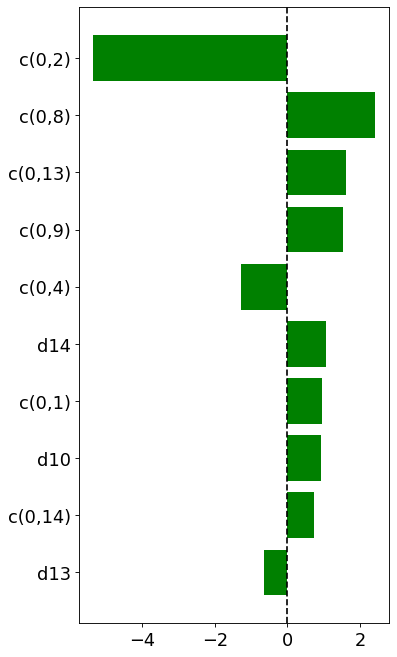

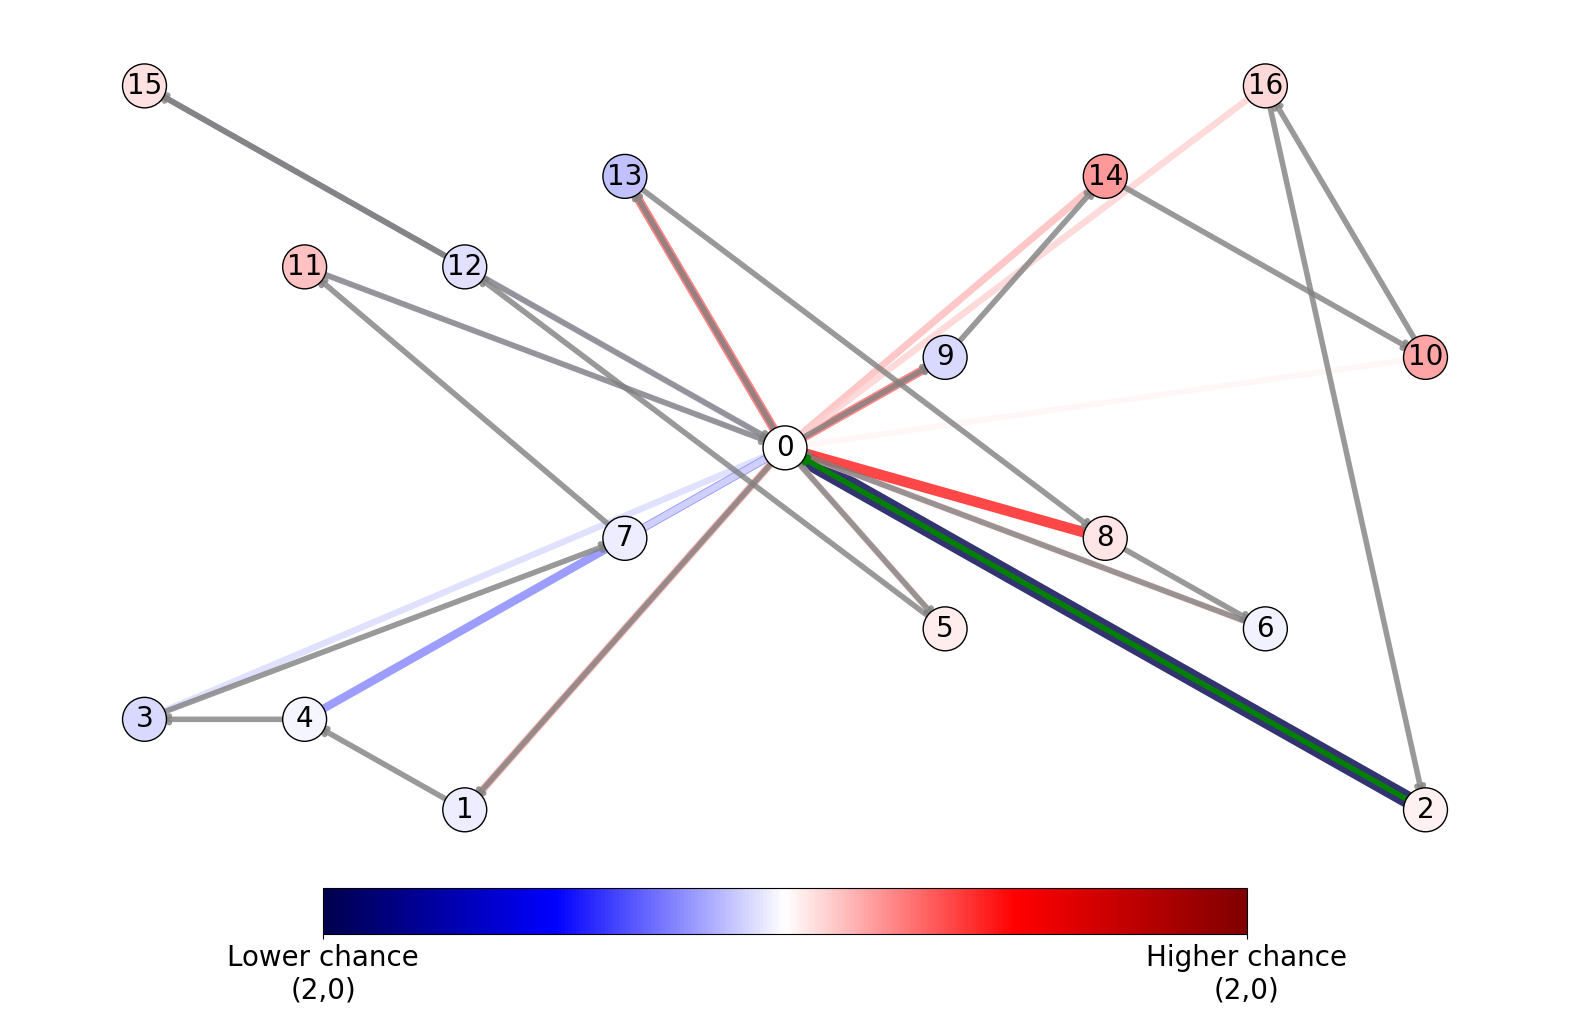

In [23]:
# Figure D.9: explanation of decision variable x_(2,0)
# (target_row = 1 is the first decision variable in kc_indx_revw, which
# corresponds to arc (2, 0))
plot_clemo_explanation(
    target_row=1,
    title_colorbar_labels=['Lower chance\n(2,0)', 'Higher chance\n(2,0)'],
    sort_by_abs=True,
    highlight_edge=('2', '0'),
    edge_filter=lambda a, b: a != 2,
)


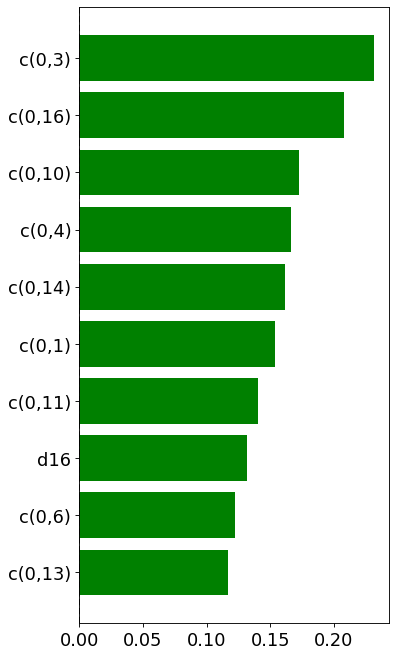

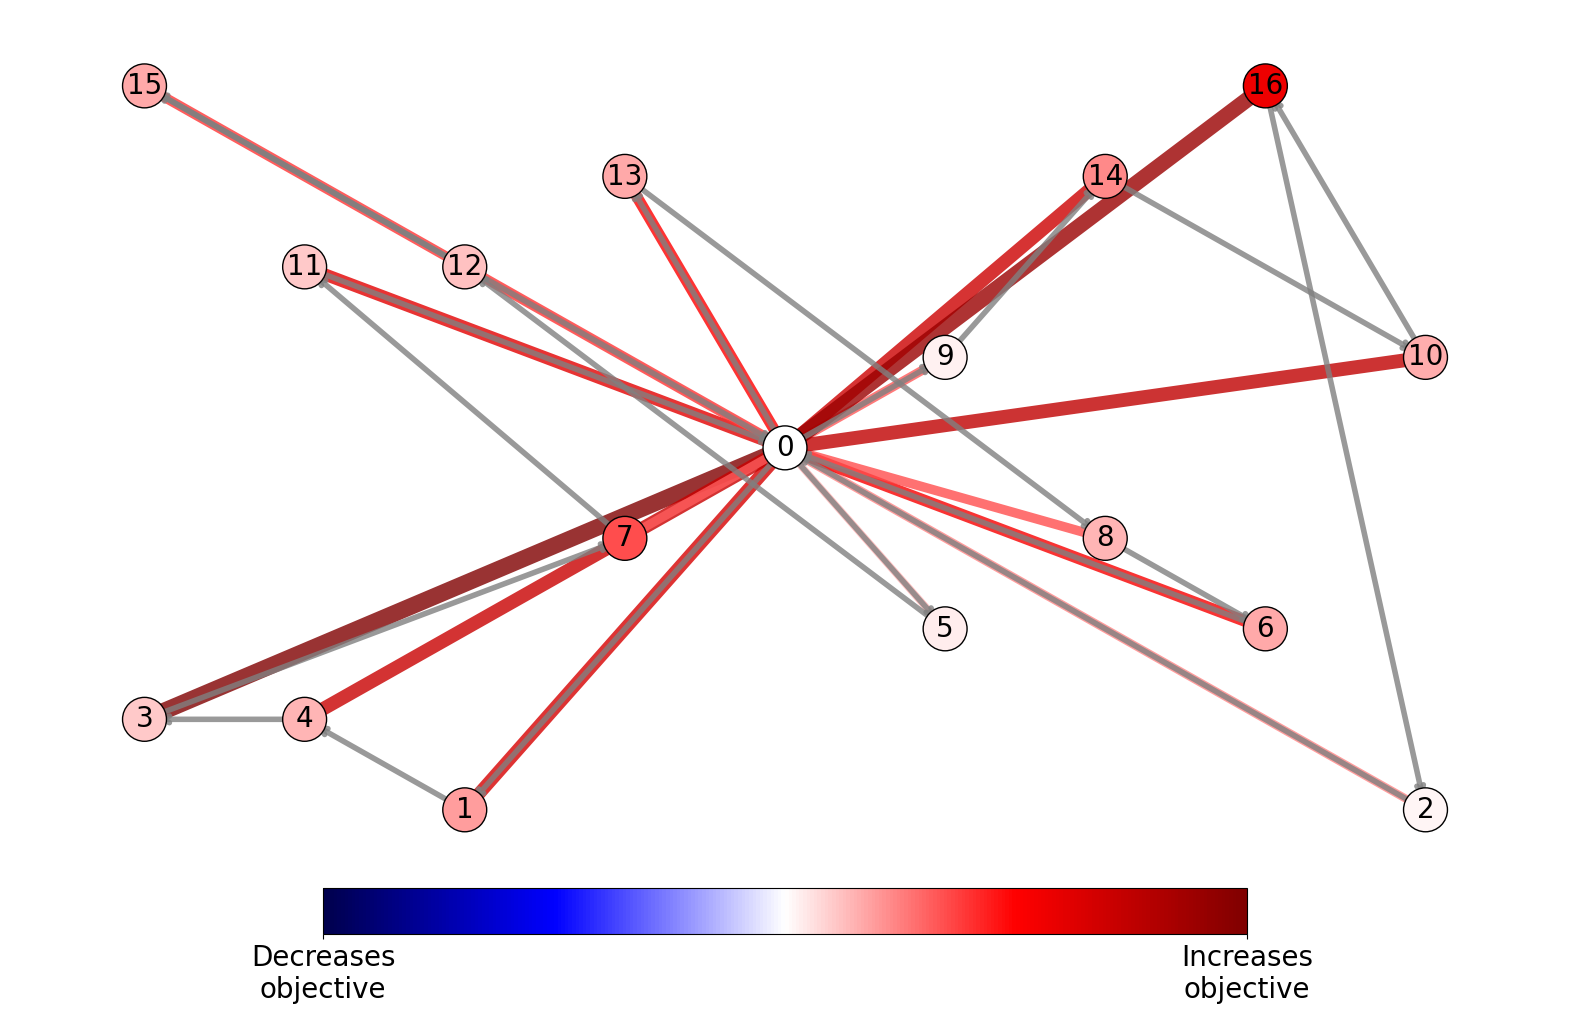

In [24]:
# Figure 3: explanation of the objective value (target_row = 0)
plot_clemo_explanation(
    target_row=0,
    title_colorbar_labels=['Decreases\nobjective', 'Increases\nobjective'],
    sort_by_abs=False,
)
